# EDA Step 1 - Load Data and Preprocessing (Poetry)

Muc tieu cua buoc dau tien:
- Load 2 dataset poetry (books + interactions).
- Chuan hoa kieu du lieu va xu ly gia tri thieu.
- Loai bo ban ghi trung lap.
- Loc outlier cho cac bien so bang quy tac IQR.

In [13]:
from pathlib import Path
import json
import pandas as pd

DATA_DIR = Path('.')
BOOKS_PATH = DATA_DIR / 'goodreads_books_poetry.json'
INTERACTIONS_PATH = DATA_DIR / 'goodreads_interactions_poetry.json'

assert BOOKS_PATH.exists(), f'Missing file: {BOOKS_PATH}'
assert INTERACTIONS_PATH.exists(), f'Missing file: {INTERACTIONS_PATH}'

BOOK_COLUMNS = ['book_id', 'authors', 'average_rating', 'ratings_count', 'publication_year']
INTERACTION_COLUMNS = ['user_id', 'book_id', 'rating', 'date_added']

def load_jsonl_selected_cols(path: Path, selected_cols, nrows=None):
    rows = []
    bad_lines = 0

    with path.open('r', encoding='utf-8') as f:
        for i, line in enumerate(f, start=1):
            if nrows is not None and i > nrows:
                break

            line = line.strip()
            if not line:
                continue

            try:
                obj = json.loads(line)
            except json.JSONDecodeError:
                bad_lines += 1
                continue

            rows.append({col: obj.get(col) for col in selected_cols})

    return pd.DataFrame(rows), bad_lines

books_raw, books_bad = load_jsonl_selected_cols(BOOKS_PATH, BOOK_COLUMNS)
interactions_raw, interactions_bad = load_jsonl_selected_cols(INTERACTIONS_PATH, INTERACTION_COLUMNS)

In [14]:
books = books_raw.copy()
interactions = interactions_raw.copy()

books['book_id'] = books['book_id'].astype('string').str.strip()
interactions['user_id'] = interactions['user_id'].astype('string').str.strip()
interactions['book_id'] = interactions['book_id'].astype('string').str.strip()

books['average_rating'] = pd.to_numeric(books['average_rating'], errors='coerce')
books['ratings_count'] = pd.to_numeric(books['ratings_count'], errors='coerce')
books['publication_year'] = pd.to_numeric(books['publication_year'], errors='coerce')
interactions['rating'] = pd.to_numeric(interactions['rating'], errors='coerce')

books = books.dropna(subset=['book_id']).drop_duplicates(subset=['book_id'])
interactions = interactions.dropna(subset=['user_id', 'book_id']).drop_duplicates(subset=['user_id', 'book_id'])

n_interactions = len(interactions)
n_users = interactions['user_id'].nunique()
n_items = interactions['book_id'].nunique()


print(f'interactions: {n_interactions}')
print(f'users: {n_users}')
print(f'items: {n_items}')

interactions: 2734350
users: 377799
items: 36514


## Step 2 - Data Visualization for Threshold and Time Window Selection

Noi dung thuc hien:
- Phan phoi user theo tung muc rating.
- Phan phoi so interaction tren moi user.
- So interaction theo nam de goi y khung thoi gian EDA.
- Tinh density va sparsity truoc khi loc threshold.
- Luu anh vao thu muc eda_outputs/visualizations.

=== BEFORE THRESHOLD FILTERING ===
interactions: 2734350
users: 377799
items: 36514
density: 0.00019821
sparsity: 0.99980179


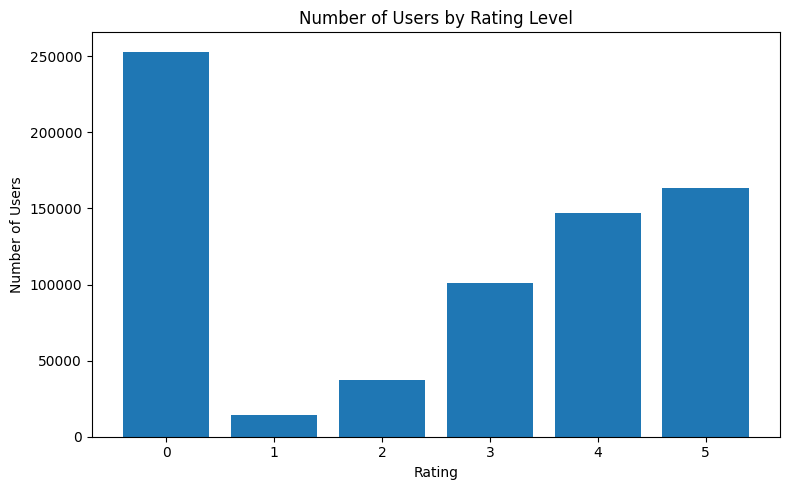


=== INTERACTIONS PER USER SUMMARY ===
avg_interactions_per_user: 7.2376
median_interactions_per_user: 3
p75: 6 | p90: 15 | p95: 26 | p99: 72
max_interactions_per_user: 2924


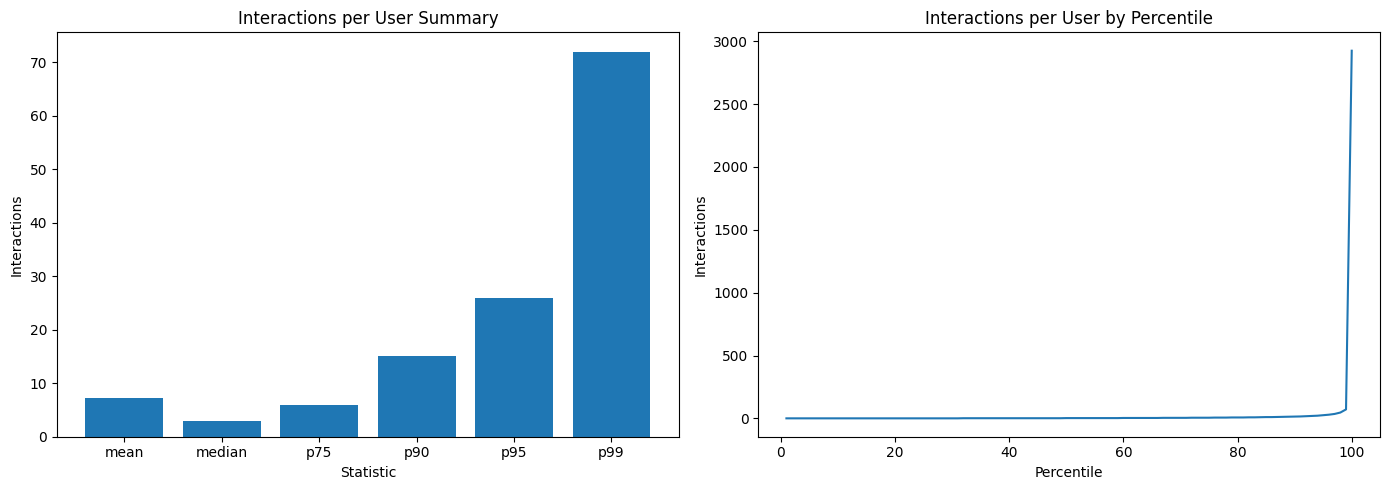

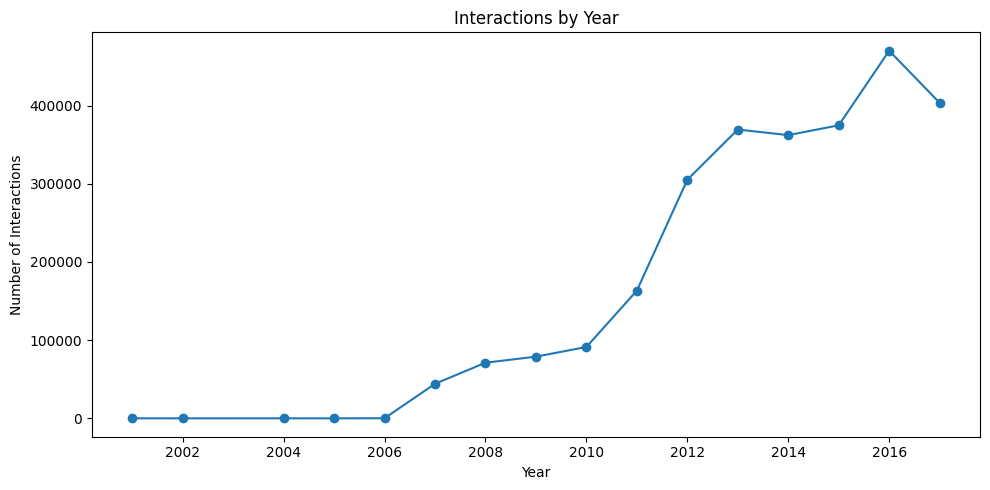

fixed_eda_time_window: 2007-2017
interactions_in_window: 2734204
users_in_window: 377797
items_in_window: 36514

Saved images:
eda_outputs\visualizations\poetry_users_per_rating.png
eda_outputs\visualizations\poetry_interactions_per_user_summary.png
eda_outputs\visualizations\poetry_interactions_by_year.png

Yearly interactions table (last 15 rows):


,interaction_year,num_interactions
1,2002,1
2,2004,10
3,2005,8
4,2006,105
5,2007,44198
6,2008,71152
7,2009,78885
8,2010,91283
9,2011,163362
10,2012,305177


In [17]:
import matplotlib.pyplot as plt

VIZ_DIR = DATA_DIR / 'eda_outputs' / 'visualizations'
VIZ_DIR.mkdir(parents=True, exist_ok=True)

# 1) Density / Sparsity before threshold filtering
n_interactions_pre = len(interactions)
n_users_pre = interactions['user_id'].nunique()
n_items_pre = interactions['book_id'].nunique()

density_pre = n_interactions_pre / (n_users_pre * n_items_pre) if n_users_pre and n_items_pre else 0.0
sparsity_pre = 1.0 - density_pre

print('=== BEFORE THRESHOLD FILTERING ===')
print(f'interactions: {n_interactions_pre}')
print(f'users: {n_users_pre}')
print(f'items: {n_items_pre}')
print(f'density: {density_pre:.8f}')
print(f'sparsity: {sparsity_pre:.8f}')

# 2) User count per rating level
rating_user_dist = (
    interactions.dropna(subset=['rating'])
    .groupby('rating')['user_id']
    .nunique()
    .sort_index()
    .reset_index(name='num_users')
)

fig1, ax1 = plt.subplots(figsize=(8, 5))
ax1.bar(rating_user_dist['rating'].astype(str), rating_user_dist['num_users'])
ax1.set_title('Number of Users by Rating Level')
ax1.set_xlabel('Rating')
ax1.set_ylabel('Number of Users')
plt.tight_layout()
rating_plot_path = VIZ_DIR / 'poetry_users_per_rating.png'
fig1.savefig(rating_plot_path, dpi=150, bbox_inches='tight')
plt.show()

# 3) Interactions per user: average + percentile-based visualization
user_interaction_counts = interactions.groupby('user_id').size().rename('interaction_count')

avg_interactions_per_user = float(user_interaction_counts.mean())
median_interactions_per_user = float(user_interaction_counts.median())
p75 = float(user_interaction_counts.quantile(0.75))
p90 = float(user_interaction_counts.quantile(0.90))
p95 = float(user_interaction_counts.quantile(0.95))
p99 = float(user_interaction_counts.quantile(0.99))
max_interactions_per_user = int(user_interaction_counts.max())

print('\n=== INTERACTIONS PER USER SUMMARY ===')
print(f'avg_interactions_per_user: {avg_interactions_per_user:.4f}')
print(f'median_interactions_per_user: {median_interactions_per_user:.0f}')
print(f'p75: {p75:.0f} | p90: {p90:.0f} | p95: {p95:.0f} | p99: {p99:.0f}')
print(f'max_interactions_per_user: {max_interactions_per_user}')

summary_labels = ['mean', 'median', 'p75', 'p90', 'p95', 'p99']
summary_values = [avg_interactions_per_user, median_interactions_per_user, p75, p90, p95, p99]

percentiles = list(range(1, 101))
percentile_values = [user_interaction_counts.quantile(p / 100) for p in percentiles]

fig2, (ax2a, ax2b) = plt.subplots(1, 2, figsize=(14, 5))
ax2a.bar(summary_labels, summary_values)
ax2a.set_title('Interactions per User Summary')
ax2a.set_xlabel('Statistic')
ax2a.set_ylabel('Interactions')

ax2b.plot(percentiles, percentile_values)
ax2b.set_title('Interactions per User by Percentile')
ax2b.set_xlabel('Percentile')
ax2b.set_ylabel('Interactions')

plt.tight_layout()
user_inter_plot_path = VIZ_DIR / 'poetry_interactions_per_user_summary.png'
fig2.savefig(user_inter_plot_path, dpi=150, bbox_inches='tight')
plt.show()

# 4) Interactions by year
date_series = pd.to_datetime(
    interactions['date_added'],
    format='%a %b %d %H:%M:%S %z %Y',
    errors='coerce',
    utc=True
)
interactions_year = interactions.assign(interaction_year=date_series.dt.year)

yearly_interactions = (
    interactions_year.dropna(subset=['interaction_year'])
    .groupby('interaction_year')
    .size()
    .reset_index(name='num_interactions')
    .sort_values('interaction_year')
)
yearly_interactions['interaction_year'] = yearly_interactions['interaction_year'].astype(int)

fig3, ax3 = plt.subplots(figsize=(10, 5))
ax3.plot(yearly_interactions['interaction_year'], yearly_interactions['num_interactions'], marker='o')
ax3.set_title('Interactions by Year')
ax3.set_xlabel('Year')
ax3.set_ylabel('Number of Interactions')
plt.tight_layout()
year_plot_path = VIZ_DIR / 'poetry_interactions_by_year.png'
fig3.savefig(year_plot_path, dpi=150, bbox_inches='tight')
plt.show()

# Fixed time window decided by group
START_YEAR = 2007
END_YEAR = 2017

interactions_in_window = interactions_year[
    interactions_year['interaction_year'].between(START_YEAR, END_YEAR, inclusive='both')
]

window_interactions = len(interactions_in_window)
window_users = interactions_in_window['user_id'].nunique()
window_items = interactions_in_window['book_id'].nunique()

print(f'fixed_eda_time_window: {START_YEAR}-{END_YEAR}')
print(f'interactions_in_window: {window_interactions}')
print(f'users_in_window: {window_users}')
print(f'items_in_window: {window_items}')

print('\nSaved images:')
print(rating_plot_path)
print(user_inter_plot_path)
print(year_plot_path)

print('\nYearly interactions table (last 15 rows):')
display(yearly_interactions.tail(15))

## Step 3 - Threshold Selection from Candidate Thresholds

Muc tieu: chon min_interactions_per_user bang cach ket hop 3 phuong phap:
- Elbow tren retention curve.
- Percentile tren phan phoi user interactions.
- Toi uu trade-off coverage va density.

Dau ra:
- Bang metric theo tung candidate threshold.
- Threshold de xuat cuoi cung.
- Cac bieu do phuc vu qua trinh chon threshold.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

THRESHOLD_DIR = DATA_DIR / 'eda_outputs' / 'threshold_selection'
THRESHOLD_DIR.mkdir(parents=True, exist_ok=True)

# Use fixed time window data for threshold selection
base_df = interactions_in_window[['user_id', 'book_id', 'rating', 'interaction_year']].copy()
base_df = base_df.dropna(subset=['user_id', 'book_id'])

# Optional: only explicit ratings for threshold tuning
USE_EXPLICIT_ONLY = False
if USE_EXPLICIT_ONLY:
    base_df = base_df[base_df['rating'].between(1, 5)]

base_interactions = len(base_df)
base_users = base_df['user_id'].nunique()
base_items = base_df['book_id'].nunique()

user_degree = base_df.groupby('user_id').size()
max_degree = int(user_degree.max()) if len(user_degree) else 1

# Candidate thresholds
candidate_thresholds = sorted(set(list(range(1, min(30, max_degree) + 1)) + [
    int(np.ceil(user_degree.quantile(0.50))) if len(user_degree) else 1,
    int(np.ceil(user_degree.quantile(0.75))) if len(user_degree) else 1,
    int(np.ceil(user_degree.quantile(0.90))) if len(user_degree) else 1,
]))
candidate_thresholds = [k for k in candidate_thresholds if k >= 1]

rows = []
for k in candidate_thresholds:
    kept_users_idx = user_degree[user_degree >= k].index
    df_k = base_df[base_df['user_id'].isin(kept_users_idx)]

    n_interactions_k = len(df_k)
    n_users_k = df_k['user_id'].nunique()
    n_items_k = df_k['book_id'].nunique()

    density_k = n_interactions_k / (n_users_k * n_items_k) if n_users_k and n_items_k else 0.0
    sparsity_k = 1.0 - density_k

    user_coverage = n_users_k / base_users if base_users else 0.0
    interaction_coverage = n_interactions_k / base_interactions if base_interactions else 0.0
    item_coverage = n_items_k / base_items if base_items else 0.0

    rows.append({
        'threshold_k': int(k),
        'users': int(n_users_k),
        'items': int(n_items_k),
        'interactions': int(n_interactions_k),
        'user_coverage': float(user_coverage),
        'item_coverage': float(item_coverage),
        'interaction_coverage': float(interaction_coverage),
        'density': float(density_k),
        'sparsity': float(sparsity_k),
    })

threshold_metrics = pd.DataFrame(rows).sort_values('threshold_k').reset_index(drop=True)

# Method 1: Elbow on interaction coverage curve
x = threshold_metrics['threshold_k'].to_numpy(dtype=float)
y = threshold_metrics['interaction_coverage'].to_numpy(dtype=float)

if len(x) >= 3:
    x_norm = (x - x.min()) / (x.max() - x.min() + 1e-12)
    y_norm = (y - y.min()) / (y.max() - y.min() + 1e-12)
    x1, y1 = x_norm[0], y_norm[0]
    x2, y2 = x_norm[-1], y_norm[-1]
    line_len = np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2) + 1e-12
    distances = np.abs((y2 - y1) * x_norm - (x2 - x1) * y_norm + x2 * y1 - y2 * x1) / line_len
    elbow_idx = int(np.argmax(distances))
    elbow_k = int(threshold_metrics.loc[elbow_idx, 'threshold_k'])
else:
    elbow_k = int(threshold_metrics['threshold_k'].iloc[0])

# Method 2: Percentile-based threshold (P75)
percentile_k = int(np.ceil(user_degree.quantile(0.75))) if len(user_degree) else 1
percentile_k = int(min(max(percentile_k, threshold_metrics['threshold_k'].min()), threshold_metrics['threshold_k'].max()))

# Method 3: Coverage + Density score
density_min = threshold_metrics['density'].min()
density_max = threshold_metrics['density'].max()
threshold_metrics['density_norm'] = (threshold_metrics['density'] - density_min) / (density_max - density_min + 1e-12)

feasible = threshold_metrics[
    (threshold_metrics['interaction_coverage'] >= 0.60) &
    (threshold_metrics['user_coverage'] >= 0.20)
]
if feasible.empty:
    feasible = threshold_metrics.copy()

feasible = feasible.copy()
feasible['score'] = (
    0.50 * feasible['interaction_coverage'] +
    0.30 * feasible['user_coverage'] +
    0.20 * feasible['density_norm']
)
coverage_density_k = int(feasible.sort_values('score', ascending=False).iloc[0]['threshold_k'])

# Final threshold is fixed for model performance target
SELECTED_K_FOR_MODEL = 10
final_k = int(min(max(SELECTED_K_FOR_MODEL, threshold_metrics['threshold_k'].min()), threshold_metrics['threshold_k'].max()))

print('\n=== THRESHOLD BY METHODS ===')
print(f'elbow_k: {elbow_k}')
print(f'percentile_k_p75: {percentile_k}')
print(f'coverage_density_k: {coverage_density_k}')
print(f'final_threshold_k: {final_k}')

# Final filtered dataset with selected threshold
kept_users_final = user_degree[user_degree >= final_k].index
filtered_df = base_df[base_df['user_id'].isin(kept_users_final)].copy()

f_interactions = len(filtered_df)
f_users = filtered_df['user_id'].nunique()
f_items = filtered_df['book_id'].nunique()
f_density = f_interactions / (f_users * f_items) if f_users and f_items else 0.0
f_sparse = 1.0 - f_density
f_avg_interaction_per_user = f_interactions / f_users if f_users else 0.0

print('\n=== AFTER FINAL THRESHOLD FILTER ===')
print(f'interactions: {f_interactions}')
print(f'users: {f_users}')
print(f'items: {f_items}')
print(f'density: {f_density:.8f}')
print(f'sparse: {f_sparse:.8f}')
print(f'avg_interaction_per_user: {f_avg_interaction_per_user:.4f}')

# Save metric table
metrics_csv_path = THRESHOLD_DIR / 'poetry_threshold_metrics.csv'
threshold_metrics.to_csv(metrics_csv_path, index=False)

# Save final filtered summary to CSV
final_summary_csv_path = THRESHOLD_DIR / 'poetry_final_filtered_summary.csv'
pd.DataFrame([
    {
        'interactions': int(f_interactions),
        'users': int(f_users),
        'items': int(f_items),
        'density': float(f_density),
        'sparse': float(f_sparse),
        'avg_interaction_per_user': float(f_avg_interaction_per_user),
        'selected_k': int(final_k)
    }
]).to_csv(final_summary_csv_path, index=False)

# Plot A: Histogram + threshold lines
fig_a, ax_a = plt.subplots(figsize=(10, 5))
ax_a.hist(user_degree.values, bins=80)
ax_a.set_title('User Interaction Histogram (for candidate threshold)')
ax_a.set_xlabel('Interactions per User')
ax_a.set_ylabel('Number of Users')
ax_a.set_xlim(left=0, right=min(max_degree, 200))
for k, c, label in [
    (elbow_k, 'tab:orange', 'elbow_k'),
    (percentile_k, 'tab:green', 'percentile_k_p75'),
    (coverage_density_k, 'tab:red', 'coverage_density_k'),
    (final_k, 'black', 'final_k'),
]:
    ax_a.axvline(k, color=c, linestyle='--', linewidth=2, label=f'{label}={k}')
ax_a.legend()
plt.tight_layout()
plot_a_path = THRESHOLD_DIR / '01_histogram_threshold_lines.png'
fig_a.savefig(plot_a_path, dpi=150, bbox_inches='tight')
plt.show()

# Plot B: Elbow curve
fig_b, ax_b = plt.subplots(figsize=(10, 5))
ax_b.plot(threshold_metrics['threshold_k'], threshold_metrics['interaction_coverage'], marker='o', label='interaction_coverage')
ax_b.axvline(elbow_k, color='tab:orange', linestyle='--', linewidth=2, label=f'elbow_k={elbow_k}')
ax_b.axvline(final_k, color='black', linestyle='--', linewidth=2, label=f'final_k={final_k}')
ax_b.set_title('Elbow Curve on Interaction Coverage')
ax_b.set_xlabel('Candidate Threshold k')
ax_b.set_ylabel('Interaction Coverage')
ax_b.legend()
plt.tight_layout()
plot_b_path = THRESHOLD_DIR / '02_elbow_interaction_coverage.png'
fig_b.savefig(plot_b_path, dpi=150, bbox_inches='tight')
plt.show()

# Plot C: CDF and CCDF
degree_freq = user_degree.value_counts().sort_index()
cdf = degree_freq.cumsum() / degree_freq.sum()
ccdf = 1.0 - cdf + (degree_freq / degree_freq.sum())

fig_c, (ax_c1, ax_c2) = plt.subplots(1, 2, figsize=(14, 5))
ax_c1.plot(cdf.index, cdf.values)
ax_c1.axvline(final_k, color='black', linestyle='--', linewidth=2, label=f'final_k={final_k}')
ax_c1.set_title('CDF of Interactions per User')
ax_c1.set_xlabel('Interactions per User')
ax_c1.set_ylabel('P(User degree <= x)')
ax_c1.legend()

ax_c2.plot(ccdf.index, ccdf.values)
ax_c2.axvline(final_k, color='black', linestyle='--', linewidth=2, label=f'final_k={final_k}')
ax_c2.set_title('CCDF of Interactions per User')
ax_c2.set_xlabel('Interactions per User')
ax_c2.set_ylabel('P(User degree >= x)')
ax_c2.legend()

plt.tight_layout()
plot_c_path = THRESHOLD_DIR / '03_cdf_ccdf_user_degree.png'
fig_c.savefig(plot_c_path, dpi=150, bbox_inches='tight')
plt.show()

# Plot D: Coverage and Density trade-off
fig_d, ax_d1 = plt.subplots(figsize=(10, 5))
ax_d1.plot(threshold_metrics['threshold_k'], threshold_metrics['interaction_coverage'], marker='o', label='interaction_coverage', color='tab:blue')
ax_d1.plot(threshold_metrics['threshold_k'], threshold_metrics['user_coverage'], marker='o', label='user_coverage', color='tab:green')
ax_d1.set_xlabel('Candidate Threshold k')
ax_d1.set_ylabel('Coverage')

ax_d2 = ax_d1.twinx()
ax_d2.plot(threshold_metrics['threshold_k'], threshold_metrics['density'], marker='s', label='density', color='tab:red')
ax_d2.set_ylabel('Density')

ax_d1.axvline(coverage_density_k, color='tab:red', linestyle='--', linewidth=2, label=f'coverage_density_k={coverage_density_k}')
ax_d1.axvline(final_k, color='black', linestyle='--', linewidth=2, label=f'final_k={final_k}')

handles1, labels1 = ax_d1.get_legend_handles_labels()
handles2, labels2 = ax_d2.get_legend_handles_labels()
ax_d1.legend(handles1 + handles2, labels1 + labels2, loc='best')
ax_d1.set_title('Coverage-Density Trade-off by Candidate Threshold')
plt.tight_layout()
plot_d_path = THRESHOLD_DIR / '04_coverage_density_tradeoff.png'
fig_d.savefig(plot_d_path, dpi=150, bbox_inches='tight')
plt.show()